100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]


Using device: cuda
Total parameters: 25718
Epoch 01 | Loss: 1.3116 | Train Acc: 51.7283% | Test Acc: 76.0000%
Epoch 02 | Loss: 0.5326 | Train Acc: 80.0250% | Test Acc: 82.6600%
Epoch 03 | Loss: 0.4430 | Train Acc: 83.8417% | Test Acc: 84.5200%
Epoch 04 | Loss: 0.3929 | Train Acc: 85.5783% | Test Acc: 85.3800%
Epoch 05 | Loss: 0.3631 | Train Acc: 86.7517% | Test Acc: 86.3800%
Epoch 06 | Loss: 0.3436 | Train Acc: 87.5383% | Test Acc: 86.6200%
Epoch 07 | Loss: 0.3275 | Train Acc: 88.0117% | Test Acc: 86.7500%
Epoch 08 | Loss: 0.3166 | Train Acc: 88.3317% | Test Acc: 87.2700%
Epoch 09 | Loss: 0.3028 | Train Acc: 88.9350% | Test Acc: 87.7100%
Epoch 10 | Loss: 0.2927 | Train Acc: 89.3117% | Test Acc: 87.2000%
Epoch 11 | Loss: 0.2852 | Train Acc: 89.5117% | Test Acc: 86.7600%
Epoch 12 | Loss: 0.2778 | Train Acc: 89.7167% | Test Acc: 88.7700%
Epoch 13 | Loss: 0.2724 | Train Acc: 89.9433% | Test Acc: 87.8200%
Epoch 14 | Loss: 0.2645 | Train Acc: 90.2033% | Test Acc: 88.4100%
Epoch 15 | Loss: 0.

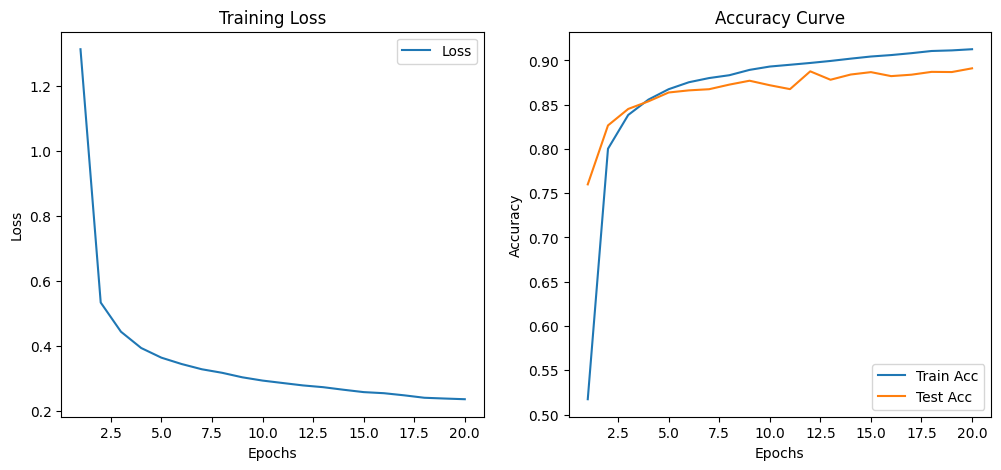

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import matplotlib.pyplot as plt

# ---------------------------
# Loading FashionMNIST dataset
# ---------------------------
train_set = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()])
)

test_set = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transforms.Compose([transforms.ToTensor()])
)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=100, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=100, shuffle=False)

# ---------------------------
# CNN model (~25K params)
# ---------------------------
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5)   # ~156 params
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=12, kernel_size=5) # ~1812 params
        self.fc1 = nn.Linear(12 * 4 * 4, 100)                                 # ~19,300 params
        self.fc2 = nn.Linear(100, 40)                                         # ~4040 params
        self.out = nn.Linear(40, 10)                                          # ~410 params

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), kernel_size=2, stride=2)
        x = F.max_pool2d(F.relu(self.conv2(x)), kernel_size=2, stride=2)
        x = x.reshape(-1, 12 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

# ---------------------------
# Helper function
# ---------------------------
def get_num_correct(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).sum().item()

# ---------------------------
# Training + Evaluation
# ---------------------------
def train_model(epochs=20, lr=0.01):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    network = Network().to(device)
    print("Total parameters:", sum(p.numel() for p in network.parameters()))

    optimizer = optim.SGD(network.parameters(), lr=lr, momentum=0.9)

    train_acc_history, test_acc_history, loss_history = [], [], []

    for epoch in range(1, epochs+1):
        network.train()
        running_loss, running_correct, total_examples = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = network(images)
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_correct += get_num_correct(logits, labels)
            total_examples += batch_size

        # Training stats
        epoch_loss = running_loss / total_examples
        epoch_acc = running_correct / total_examples
        loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc)

        # Test stats
        network.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                logits = network(images)
                correct += get_num_correct(logits, labels)
                total += labels.size(0)
        test_acc = correct / total
        test_acc_history.append(test_acc)

        print(f"Epoch {epoch:02d} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4%} | Test Acc: {test_acc:.4%}")

    # ---------------------------
    # Plot results
    # ---------------------------
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), loss_history, label="Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.title("Training Loss"); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), train_acc_history, label="Train Acc")
    plt.plot(range(1, epochs+1), test_acc_history, label="Test Acc")
    plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.title("Accuracy Curve"); plt.legend()

    plt.show()

if __name__ == '__main__':
    train_model(epochs=20, lr=0.01)
